In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sashimi_c import *
hm = halo_model()

In [ ]:
obs = subhalo_observables(
    M0_per_Msun=1.8e12, #M200, M in plot Mvir?
    redshift=0,
    M0_at_redshift=False,
    #logmamin = -6#->0.214 Minimum value of subhalo mass at accretion defined as log_{10}(m_{min}/Msun). 
    #logmamin = 6#->0.194 Minimum value of subhalo mass at accretion defined as log_{10}(m_{min}/Msun). 
    #logmamin = np.log10(1.73e10 / hm.h)#->0.150
)

fsh =  0.160 for M200 = 1.82e+12, Mvir = 2.12e+12
fsh =  0.252 for M200 = 5.89e+14, Mvir = 7.23e+14


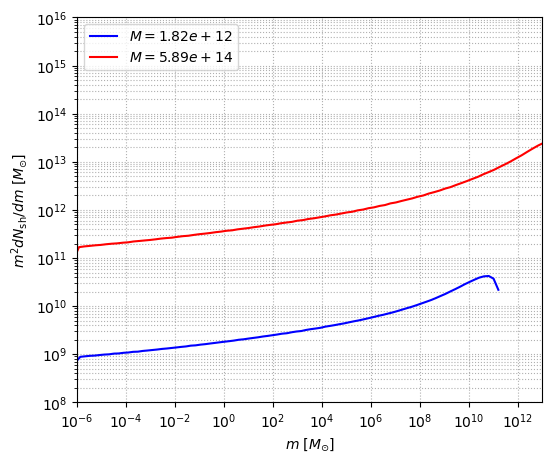

In [43]:
plt.figure(figsize=(6,5))
obs = subhalo_observables(
    M0_per_Msun=10**12.26,
    redshift=0,
    M0_at_redshift=False
)
fsh = obs.mass_fraction()
m,dNdlnm = obs.mass_function()
print(fr"fsh =  {fsh:.3f} for M200 = {obs.M0:.2e}, Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e}")
plt.loglog(m,m*dNdlnm,label = rf'$M={obs.M0:.2e}$',color='b')

obs = subhalo_observables(
    M0_per_Msun=10**14.77,
    redshift=0,
    M0_at_redshift=False
)
fsh = obs.mass_fraction()
m,dNdlnm = obs.mass_function()
print(fr"fsh =  {fsh:.3f} for M200 = {obs.M0:.2e}, Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e}")
plt.loglog(m,m*dNdlnm,label = rf'$M={obs.M0:.2e}$',color='r')

plt.xlim(1.e-6,1.e13)
plt.ylim(1.e8,1.e16)
plt.xlabel(r'$m$ [$M_{\odot}$]')
plt.ylabel(r'$m^{2}dN_{\rm sh}/dm$ [$M_{\odot}$]')
plt.grid(True, which='both', ls=':')
plt.legend(loc='upper left')
plt.show()

Compare this with Fig. 2 (top) of Hiroshima et al. arXiv:1803.07691.
-> Looks like my values are slightly higher (look at the peak of the blue line: between 1e10 and 2e10 in the paper, at 4e10 for me. Or the red line at m=1e-3: <2e11 in the paper and >2e11 for me) Maybe because the host mass M in the plots is different from the input M200 to SASHIMI

fsh =  0.159 for M200 = 1.57e+12, Mvir = 1.82e+12
fsh =  0.247 for M200 = 4.81e+14, Mvir = 5.89e+14


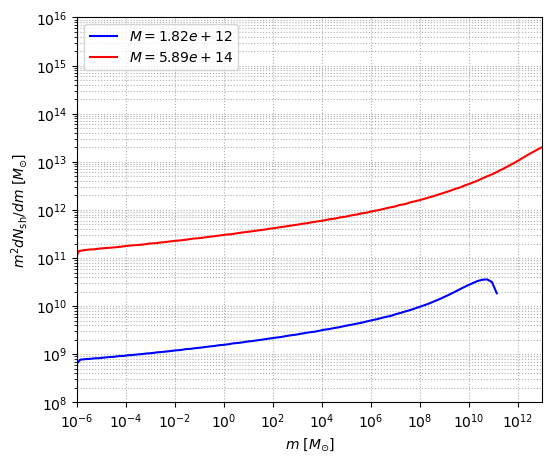

In [77]:
z=0
M_list   = np.logspace(0.,3.,1000)*1e12
fint      = interp1d(hm.Mvir_from_M200_fit(M_list, z), M_list)

plt.figure(figsize=(6,5))
obs = subhalo_observables(
    M0_per_Msun=fint(1.82e12),
    redshift=0,
    M0_at_redshift=False
)
fsh = obs.mass_fraction()
m,dNdlnm = obs.mass_function()
print(fr"fsh =  {fsh:.3f} for M200 = {obs.M0:.2e}, Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e}")
plt.loglog(m,m*dNdlnm,label = rf'$M={hm.Mvir_from_M200_fit(obs.M0,0):.2e}$',color='b')

obs = subhalo_observables(
    M0_per_Msun=fint(5.89e14),
    redshift=0,
    M0_at_redshift=False
)
fsh = obs.mass_fraction()
m,dNdlnm = obs.mass_function()
print(fr"fsh =  {fsh:.3f} for M200 = {obs.M0:.2e}, Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e}")
plt.loglog(m,m*dNdlnm,label = rf'$M={hm.Mvir_from_M200_fit(obs.M0,0):.2e}$',color='r')

plt.xlim(1.e-6,1.e13)
plt.ylim(1.e8,1.e16)
plt.xlabel(r'$m$ [$M_{\odot}$]')
plt.ylabel(r'$m^{2}dN_{\rm sh}/dm$ [$M_{\odot}$]')
plt.grid(True, which='both', ls=':')
plt.legend(loc='upper left')
plt.show()

fsh =  0.286 for M200 = 7.60e+06, Mvir = 8.45e+06
fsh =  0.315 for M200 = 9.15e+07, Mvir = 1.02e+08


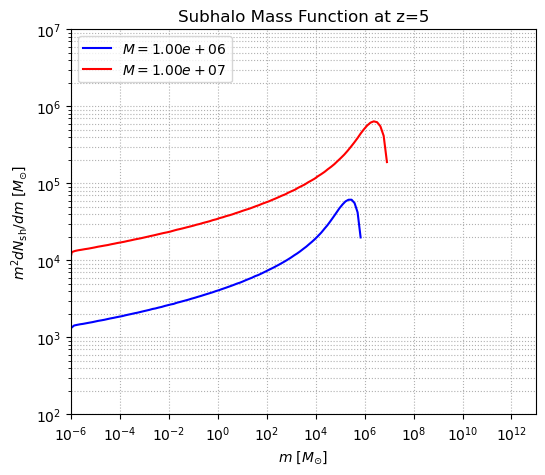

In [89]:
z=5

plt.figure(figsize=(6,5))
obs = subhalo_observables(
    M0_per_Msun=1.e6,
    redshift=z,
    M0_at_redshift=True
)
fsh = obs.mass_fraction()
m,dNdlnm = obs.mass_function()
print(fr"fsh =  {fsh:.3f} for M200 = {obs.M0:.2e}, Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e}")
plt.loglog(m,m*dNdlnm,label = rf'$M={1e6:.2e}$',color='b')

obs = subhalo_observables(
    M0_per_Msun=1.e7,
    redshift=z,
    M0_at_redshift=True
)
fsh = obs.mass_fraction()
m,dNdlnm = obs.mass_function()
print(fr"fsh =  {fsh:.3f} for M200 = {obs.M0:.2e}, Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e}")
plt.loglog(m,m*dNdlnm,label = rf'$M={1e7:.2e}$',color='r')

plt.xlim(1.e-6,1.e13)
plt.ylim(1.e2,1.e7)
plt.xlabel(r'$m$ [$M_{\odot}$]')
plt.ylabel(r'$m^{2}dN_{\rm sh}/dm$ [$M_{\odot}$]')
plt.grid(True, which='both', ls=':')
plt.legend(loc='upper left')
plt.title('Subhalo Mass Function at z=5')
plt.show()

Compare this to the bottom plot in fig.2. Blue peak: factor 2 higher in my plot, same for red peak

In [ ]:
obs = subhalo_observables(
    M0_per_Msun=1e14,
    redshift=0,
    M0_at_redshift=False,
    logmamin = 10
)
fsh = obs.mass_fraction()
print(f"f_sh = {fsh:.3f} for M200 = {obs.M0:.2e}/ Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e}")

f_sh = 0.158 for M200 = 1.00e+14/ Mvir = 1.20e+14


In [79]:
obs = subhalo_observables(
    M0_per_Msun=1e15,
    redshift=0,
    M0_at_redshift=False,
    logmamin = 10
)
fsh = obs.mass_fraction()
print(f"f_sh = {fsh:.3f} for M200 = {obs.M0:.2e}/ Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e}")

f_sh = 0.223 for M200 = 1.00e+15/ Mvir = 1.24e+15


In [78]:
obs = subhalo_observables(
    M0_per_Msun=1e14,
    redshift=1,
    M0_at_redshift=False,
    logmamin = 10
)
fsh = obs.mass_fraction()
print(f"f_sh = {fsh:.3f} for M200 = {obs.M0:.2e}/ Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e} at z=1")

f_sh = 0.274 for M200 = 1.00e+14/ Mvir = 1.20e+14 at z=1


In [90]:
Mvir = hm.Mvir_from_M200_fit(1e14,0)
obs = subhalo_observables(
    M0_per_Msun=1e14, #M200
    redshift=0,
    M0_at_redshift=False,
    logmamin = 10, #M200
    logmamax = None #M200
)
fsh = np.sum(obs.m0*obs.weight)/Mvir #m0 is virial subhalo mass
print(f"f_sh = {fsh:.3f} for M200 = {obs.M0:.2e}/ Mvir = {hm.Mvir_from_M200_fit(obs.M0,0):.2e} (divided by Mvir instead of M200)")

f_sh = 0.131 for M200 = 1.00e+14/ Mvir = 1.20e+14 (divided by Mvir instead of M200)


fig. 5: "Boost factor Bsh = Ltotal  sh /Lhost as a function of the host mass Mhost (defined as M200)"
-> is this always the definition for the host mass used in the plots?